# Notebook 10: Note Length Regression

Predict how long a clinical note section should be (word count) given the dialogue text.

This is a regression task using the `section_text` column from MTS-Dialog, which we hadn't used yet. Comparing OLS, Ridge, Lasso, and tree-based regressors.

Target (note_length) statistics:
count    1201.0
mean       40.6
std        67.0
min         1.0
25%         5.0
50%        14.0
75%        45.0
max      1020.0
Name: note_length, dtype: float64


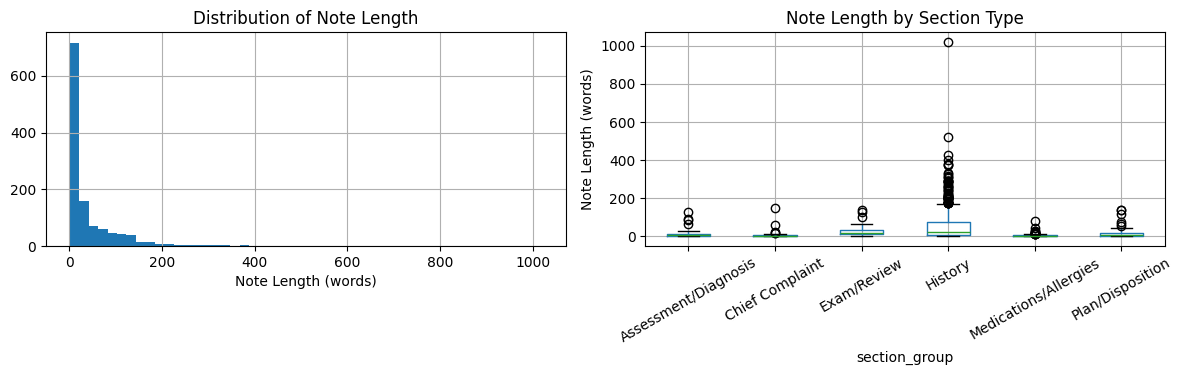

In [ ]:
import pandas as pd

import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

train_df = pd.read_csv('../data/raw/MTS-Dialog-TrainingSet.csv')

section_mapping = {
    'GENHX': 'History', 'FAM/SOCHX': 'History', 'PASTMEDICALHX': 'History',
    'PASTSURGICAL': 'History', 'OTHER_HISTORY': 'History', 'GYNHX': 'History',
    'CC': 'Chief Complaint', 'ROS': 'Exam/Review', 'EXAM': 'Exam/Review',
    'ALLERGY': 'Medications/Allergies', 'MEDICATIONS': 'Medications/Allergies',
    'IMMUNIZATIONS': 'Medications/Allergies',
    'ASSESSMENT': 'Assessment/Diagnosis', 'DIAGNOSIS': 'Assessment/Diagnosis',
    'PLAN': 'Plan/Disposition', 'DISPOSITION': 'Plan/Disposition',
    'EDCOURSE': 'Plan/Disposition', 'PROCEDURES': 'Plan/Disposition',
    'IMAGING': 'Plan/Disposition', 'LABS': 'Plan/Disposition',
}
train_df['section_group'] = train_df['section_header'].map(section_mapping)
train_df['note_length'] = train_df['section_text'].str.split().str.len()

print(f"Target (note_length) statistics:")
print(train_df['note_length'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df['note_length'].hist(bins=50, ax=axes[0])
axes[0].set_xlabel('Note Length (words)')
axes[0].set_title('Distribution of Note Length')

train_df.boxplot(column='note_length', by='section_group', ax=axes[1], rot=30)

axes[1].set_ylabel('Note Length (words)')
axes[1].set_title('Note Length by Section Type')
plt.suptitle('')
plt.tight_layout()
plt.show()

## Features

In [ ]:
tfidf = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1,2), min_df=2, max_df=0.95)
X_tfidf = tfidf.fit_transform(train_df['dialogue'])

def extract_dialogue_features(df):
    features = pd.DataFrame()
    features['word_count'] = df['dialogue'].str.split().str.len()
    features['turn_count'] = df['dialogue'].str.count(r'Doctor:|Patient:|\[doctor\]|\[patient\]')
    features['doctor_words'] = df['dialogue'].apply(
        lambda x: len(' '.join(re.findall(r'(?:Doctor|doctor).*?(?=Patient|patient|$)', x, re.DOTALL)).split()))
    features['patient_words'] = df['dialogue'].apply(
        lambda x: len(' '.join(re.findall(r'(?:Patient|patient).*?(?=Doctor|doctor|$)', x, re.DOTALL)).split()))
    features['avg_turn_length'] = features['word_count'] / features['turn_count'].clip(lower=1)
    return features

X_dialogue = extract_dialogue_features(train_df)
X_combined = hstack([X_tfidf, X_dialogue.values])

scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform(X_combined)

y = train_df['note_length'].values

print(f"Features: {X_scaled.shape[1]}")
print(f"Target mean: {y.mean():.1f}, std: {y.std():.1f}")

Features: 505
Target mean: 40.6, std: 66.9


## Model Comparison (5-Fold CV)

Comparing OLS, Ridge, Lasso (the regularized regression methods from class) and some tree-based regressors. Using R² (higher is better) and RMSE (lower is better).

In [4]:
models = {
    'OLS': LinearRegression(),
    'Ridge (alpha=1)': Ridge(alpha=1),
    'Ridge (alpha=10)': Ridge(alpha=10),
    'Ridge (alpha=100)': Ridge(alpha=100),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1, max_iter=5000),
    'Lasso (alpha=1)': Lasso(alpha=1, max_iter=5000),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=42),
}

print("5-Fold Cross-Validation\n")
print(f"{'Model':30s}  {'R2':>8s}  {'RMSE':>8s}")
print("-" * 52)

cv_results = {}
for name, model in models.items():
    r2_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
    rmse_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='neg_root_mean_squared_error')
    cv_results[name] = {'r2': r2_scores, 'rmse': -rmse_scores}
    print(f"{name:30s}  {r2_scores.mean():8.3f}  {-rmse_scores.mean():8.1f}")

5-Fold Cross-Validation

Model                                 R2      RMSE
----------------------------------------------------
OLS                                0.591      40.1
Ridge (alpha=1)                    0.738      33.3
Ridge (alpha=10)                   0.732      34.2
Ridge (alpha=100)                  0.479      47.7
Lasso (alpha=0.1)                  0.797      29.0
Lasso (alpha=1)                    0.730      34.4
Decision Tree                      0.519      44.4
Random Forest                      0.722      34.3
Gradient Boosting                  0.718      34.6


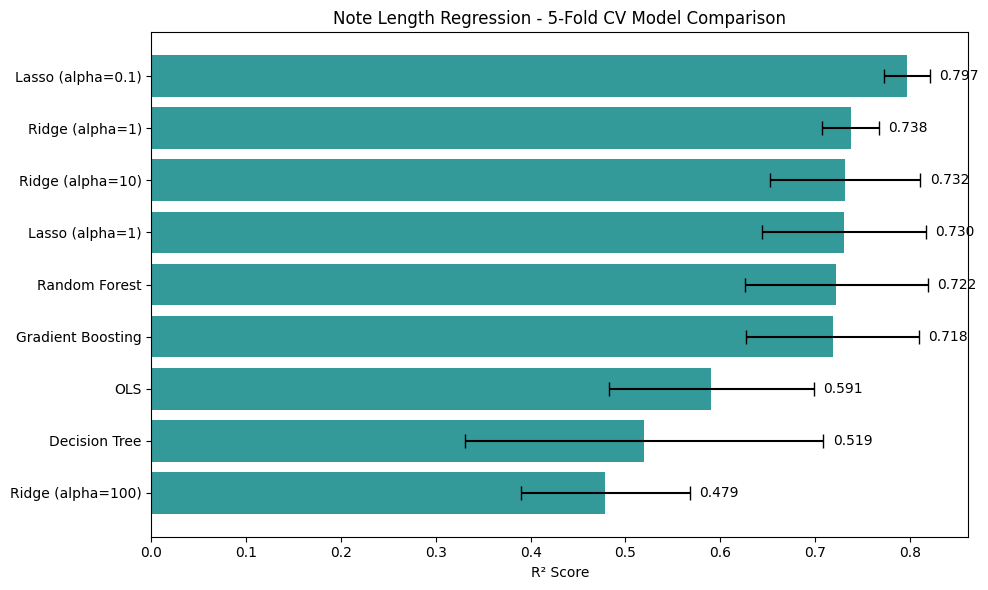

In [ ]:
# Visualize R² comparison
fig, ax = plt.subplots(figsize=(10, 6))
names = list(cv_results.keys())

r2_means = [cv_results[n]['r2'].mean() for n in names]
r2_stds = [cv_results[n]['r2'].std() for n in names]

order = np.argsort(r2_means)
bars = ax.barh([names[i] for i in order], [r2_means[i] for i in order],
               xerr=[r2_stds[i] for i in order], capsize=5, color='teal', alpha=0.8)
ax.set_xlabel('R² Score')
ax.set_title('Note Length Regression - 5-Fold CV Model Comparison')

for bar, idx in zip(bars, order):
    ax.text(r2_means[idx] + r2_stds[idx] + 0.01, bar.get_y() + bar.get_height()/2,
            f'{r2_means[idx]:.3f}', va='center')

plt.tight_layout()
plt.show()

## Regularization Effect: Ridge vs Lasso

Showing how the regularization strength (alpha) affects the number of non-zero coefficients and overall performance.

/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 467.8881894782535, tolerance: 426.4682164412071
  model = cd_fast.sparse_enet_coordinate_descent(


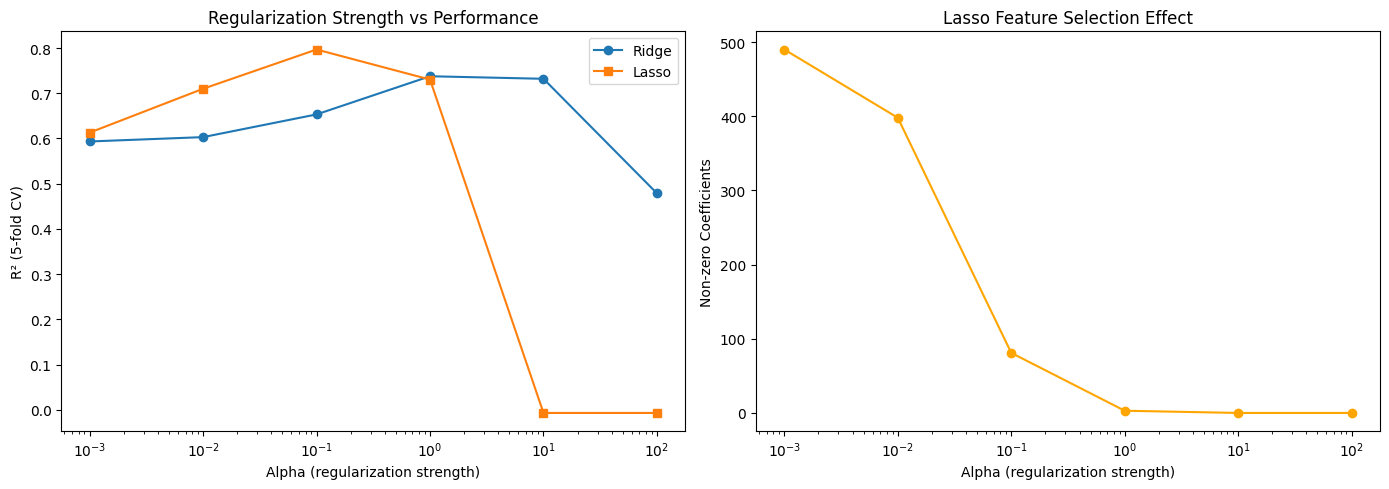

Lasso sparsity:
  alpha= 0.001: 490/505 features kept
  alpha=  0.01: 398/505 features kept
  alpha=   0.1: 81/505 features kept
  alpha=     1: 3/505 features kept
  alpha=    10: 0/505 features kept
  alpha=   100: 0/505 features kept


In [6]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
ridge_r2, lasso_r2, lasso_nonzero = [], [], []

for alpha in alphas:
    r = Ridge(alpha=alpha).fit(X_scaled, y)
    l = Lasso(alpha=alpha, max_iter=5000).fit(X_scaled, y)

    ridge_r2.append(cross_val_score(Ridge(alpha=alpha), X_scaled, y, cv=5, scoring='r2').mean())
    lasso_r2.append(cross_val_score(Lasso(alpha=alpha, max_iter=5000), X_scaled, y, cv=5, scoring='r2').mean())
    lasso_nonzero.append(np.sum(l.coef_ != 0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(alphas, ridge_r2, 'o-', label='Ridge')
axes[0].semilogx(alphas, lasso_r2, 's-', label='Lasso')
axes[0].set_xlabel('Alpha (regularization strength)')
axes[0].set_ylabel('R² (5-fold CV)')
axes[0].set_title('Regularization Strength vs Performance')
axes[0].legend()

axes[1].semilogx(alphas, lasso_nonzero, 'o-', color='orange')
axes[1].set_xlabel('Alpha (regularization strength)')
axes[1].set_ylabel('Non-zero Coefficients')
axes[1].set_title('Lasso Feature Selection Effect')

plt.tight_layout()
plt.show()

print("Lasso sparsity:")
for a, nz in zip(alphas, lasso_nonzero):
    print(f"  alpha={a:>6}: {nz}/{X_scaled.shape[1]} features kept")

## Predicted vs Actual

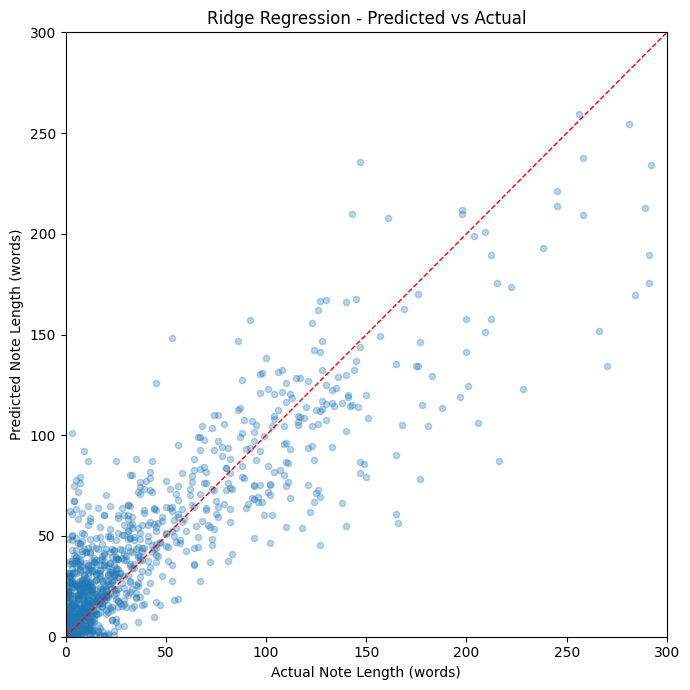

Mean residual: -0.16
Median absolute error: 11.3 words


In [7]:
from sklearn.model_selection import cross_val_predict

best_model = Ridge(alpha=10)
y_pred = cross_val_predict(best_model, X_scaled, y, cv=5)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y, y_pred, alpha=0.3, s=20)
ax.plot([0, y.max()], [0, y.max()], 'r--', linewidth=1)
ax.set_xlabel('Actual Note Length (words)')
ax.set_ylabel('Predicted Note Length (words)')
ax.set_title('Ridge Regression - Predicted vs Actual')
ax.set_xlim(0, 300)
ax.set_ylim(0, 300)
plt.tight_layout()
plt.show()

residuals = y - y_pred
print(f"Mean residual: {residuals.mean():.2f}")
print(f"Median absolute error: {np.median(np.abs(residuals)):.1f} words")